---

# IF3270 Pembelajaran Mesin | Praktikum 3
## Convolutional Neural Network

---

**Nomor Kelompok:** xx

**Anggota Kelompok:**
- Nama (NIM)
- Nama (NIM)

## Daftar Isi

0. [**Inisialisasi**](#0)
1. [**Analisis Data Eksploratif**](#1)
2. [**Pembagian Data Latih dan Validasi**](#2)
3. [**Pembersihan dan Prapemrosesan Data**](#3)
4. [**Pemodelan dan Validasi**](#4)
5. [**Analisis Kesalahan**](#5)
6. [**Insights**](#6)

---

# Inisialisasi <a name="0"></a>

---

## Instalasi Dependensi

In [1]:
%pip install -q gdown kaggle torch torchvision torchaudio
%pip install -q opencv-python-headless Pillow scikit-learn matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Impor Pustaka

In [2]:
from collections import Counter
import hashlib
import os
import platform
import random
import shutil
import subprocess
import sys
import zipfile
import warnings
from pathlib import Path

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.version.cuda)
print('Device  :', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch : 2.10.0+cu128
CUDA    : 12.8
Device  : cuda


## Pengaturan Seed

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

## Settings

Kelas `Settings` memusatkan seluruh konfigurasi eksperimen, mencakup jalur data, *hyperparameter* pelatihan, dan flag mode. Jalur data diselesaikan secara otomatis bergantung pada lingkungan eksekusi, yaitu Kaggle atau lokal. Ubah `MODE` menjadi `'inference'` untuk melewati pelatihan dan langsung memuat *checkpoint* tersimpan.

In [4]:
class Settings:
    SEED = 42
    MODE = 'train'   # 'train' | 'inference'

    # Kelas target, urutan harus sesuai encoding integer di CSV
    TARGET_COL  = 'Species_Label'
    CLASS_NAMES = ['cat', 'dog']   # index 0 = kucing, 1 = anjing
    N_CLASSES   = len(CLASS_NAMES)
    LABEL2IDX   = {name: i for i, name in enumerate(CLASS_NAMES)}

    # Pelatihan
    EPOCHS      = 30
    BATCH_SIZE  = 32
    LR_ALEX          = 1e-4    # LR AlexNet dari nol
    LR_HEAD          = 1e-3    # LR kepala pretrained (fase warm-up & fine-tune)
    LR_BACKBONE      = 1e-4    # LR backbone pada fase fine-tune
    WARMUP_PATIENCE      = 2   # toleransi epoch tanpa perbaikan val_loss di fase warm-up
    WARMUP_MIN_DELTA     = 1e-3  # ambang perbaikan val_loss yang dianggap signifikan
    EARLY_STOP_PATIENCE  = 5   # toleransi epoch tanpa perbaikan val_f1 sebelum berhenti
    UNFREEZE_BLOCKS  = 2       # jumlah blok terakhir backbone yang di-unfreeze
    COSINE_T_MAX     = 15      # T_max CosineAnnealingLR di fase 2 (tetap, tidak bergantung EPOCHS)
    WEIGHT_DECAY = 1e-4
    VAL_SPLIT   = 0.2
    USE_AMP     = True
    IMG_SIZE    = (224, 224)

    # Normalisasi (statistik ImageNet)
    IMAGENET_MEAN = (0.485, 0.456, 0.406)
    IMAGENET_STD  = (0.229, 0.224, 0.225)

    # Opsi pretrained (IMAGENET1K_V2 weights only, CNN murni):
    #   'resnext101_32x8d'   ResNeXt-101-32x8d  82.8% top-1
    #   'wide_resnet101_2'   Wide-ResNet-101-2  82.5% top-1
    #   'resnet152'          ResNet-152         82.3% top-1
    #   'wide_resnet50_2'    Wide-ResNet-50-2   81.6% top-1
    #   'resnet101'          ResNet-101         81.9% top-1
    #   'resnext50_32x4d'    ResNeXt-50-32x4d   81.2% top-1
    #   'resnet50'           ResNet-50          80.9% top-1
    #   'mobilenet_v3_large' MobileNet-V3-L     75.3% top-1
    PRETRAINED_MODEL = 'resnext101_32x8d'

    # Visualisasi
    PALETTE = 'flare'

    # DataLoader
    NUM_WORKERS = 1

    # Jalur data, diselesaikan otomatis berdasarkan lingkungan eksekusi
    _ON_KAGGLE  = Path('/kaggle/input').exists()
    _LOCAL_DATA = Path('dataset')
    _KAGGLE_DATA = Path('/kaggle/input/competitions/praktikum-2-if-3270-ml')

    DATA_DIR   = _KAGGLE_DATA if _ON_KAGGLE else _LOCAL_DATA
    IMAGES_DIR     = DATA_DIR / 'images' / 'images'
    TRAIN_IMG_DIR  = IMAGES_DIR / 'train'
    TEST_IMG_DIR   = IMAGES_DIR / 'test'
    TRAIN_CSV  = DATA_DIR / 'train.csv'
    TEST_CSV   = DATA_DIR / 'test.csv'

    _BASE_OUT = Path('/kaggle/working') if _ON_KAGGLE else Path('output')
    OUTPUT_DIR      = _BASE_OUT / 'prak3'
    CHECKPOINT_ALEX = OUTPUT_DIR / 'alexnet_best.pth'
    CHECKPOINT_FT   = OUTPUT_DIR / 'finetune_best.pth'
    SUBMISSION_ALEX = OUTPUT_DIR / 'submission_alexnet.csv'
    SUBMISSION_FT   = OUTPUT_DIR / 'submission_finetune.csv'


CFG = Settings()
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = CFG.OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Python      : {sys.version.split()[0]}')
print(f'OS          : {platform.system()} {platform.release()}')
print(f'CWD         : {os.getcwd()}')
print(f'Lingkungan  : {"Kaggle" if CFG._ON_KAGGLE else "Lokal"}')
print(f'DATA_DIR    : {CFG.DATA_DIR}  exists={CFG.DATA_DIR.exists()}')
print(f'TRAIN_IMG_DIR: {CFG.TRAIN_IMG_DIR}  exists={CFG.TRAIN_IMG_DIR.exists()}')
print(f'TEST_IMG_DIR : {CFG.TEST_IMG_DIR}  exists={CFG.TEST_IMG_DIR.exists()}')
print(f'OUTPUT_DIR  : {CFG.OUTPUT_DIR}')
print(f'DEVICE      : {DEVICE}')

Python      : 3.12.12
OS          : Linux 6.6.113+
CWD         : /kaggle/working
Lingkungan  : Kaggle
DATA_DIR    : /kaggle/input/competitions/praktikum-2-if-3270-ml  exists=True
TRAIN_IMG_DIR: /kaggle/input/competitions/praktikum-2-if-3270-ml/images/images/train  exists=True
TEST_IMG_DIR : /kaggle/input/competitions/praktikum-2-if-3270-ml/images/images/test  exists=True
OUTPUT_DIR  : /kaggle/working/prak3
DEVICE      : cuda


## Unduh Dataset

Apabila direktori *dataset* tidak ditemukan, sel ini mengunduhnya secara otomatis. *Download* dicoba terlebih dahulu melalui *gdown* (Google Drive); bila gagal, Kaggle API digunakan sebagai cadangan. Setelah diunduh, arsip zip diekstraksi dan file sementara dihapus.

In [5]:
# Konfigurasi gdown
GDRIVE_FILE_ID = '1bY1il9qQiE1dHFRgriPiuumakfgUuuyC'  # perbarui jika URL berubah
KAGGLE_COMPETITION = 'praktikum-2-if-3270-ml'

def _extract(zip_path: Path, dest: Path) -> None:
    print(f'Mengekstrak {zip_path.name} ...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dest)
    zip_path.unlink()
    print('[OK] Ekstraksi selesai')

def _download_gdown(dest_dir: Path) -> bool:
    try:
        import gdown
        url = f'https://drive.google.com/uc?export=download&id={GDRIVE_FILE_ID}'
        zip_path = dest_dir / 'dataset.zip'
        dest_dir.mkdir(parents=True, exist_ok=True)
        gdown.download(url, str(zip_path), quiet=False)
        _extract(zip_path, dest_dir)
        # tangani zip bersarang (images.zip)
        inner = dest_dir / 'images.zip'
        if inner.exists():
            _extract(inner, dest_dir)
        return True
    except Exception as e:
        print(f'[gdown gagal] {e}')
        return False

def _download_kaggle(dest_dir: Path) -> bool:
    try:
        import subprocess
        # kredensial Kaggle harus berada di ~/.kaggle/kaggle.json atau variabel KAGGLE_*
        dest_dir.mkdir(parents=True, exist_ok=True)
        result = subprocess.run(
            ['kaggle', 'competitions', 'download', '-c', KAGGLE_COMPETITION,
             '-p', str(dest_dir)],
            capture_output=True, text=True
        )
        print(result.stdout)
        if result.returncode != 0:
            raise RuntimeError(result.stderr)
        for zip_path in dest_dir.glob('*.zip'):
            _extract(zip_path, dest_dir)
        return True
    except Exception as e:
        print(f'[Kaggle API gagal] {e}')
        return False

# Deteksi otomatis dan unduh
if not CFG.TRAIN_IMG_DIR.exists():
    print(f'Dataset tidak ditemukan di {CFG.DATA_DIR}. Mencoba mengunduh...')
    ok = _download_gdown(CFG.DATA_DIR)
    if not ok:
        print('Mencoba ulang dengan Kaggle API...')
        ok = _download_kaggle(CFG.DATA_DIR)
    if not ok:
        raise RuntimeError(
            'Unduhan dataset gagal. Letakkan dataset secara manual di: ' + str(CFG.DATA_DIR)
        )
else:
    print(f'[OK] Dataset ditemukan di {CFG.TRAIN_IMG_DIR}')

[OK] Dataset ditemukan di /kaggle/input/competitions/praktikum-2-if-3270-ml/images/images/train


## Muat Dataset

In [6]:
train_df = pd.read_csv(CFG.TRAIN_CSV)
test_df  = pd.read_csv(CFG.TEST_CSV)

# Encode label ke integer jika kolom bertipe string
if train_df[CFG.TARGET_COL].dtype == object:
    train_df[CFG.TARGET_COL] = train_df[CFG.TARGET_COL].map(CFG.LABEL2IDX)
    test_df[CFG.TARGET_COL]  = test_df[CFG.TARGET_COL].map(CFG.LABEL2IDX)
    print(f'Label dienkode: {CFG.LABEL2IDX}')

print(f'Sampel latih : {len(train_df)}')
print(f'Sampel uji   : {len(test_df)}')
train_df.head()

Sampel latih : 12500
Sampel uji   : 12500


,Image,Species_Label
0,eceecd68-aae4-41b5-86fe-5a0b954b038e.jpg,0
1,224f5a7b-e6ad-479d-a6ae-a26812e4e038.jpg,0
2,461e8e5f-8221-441c-971a-aecfcaf05564.jpg,0
3,a62fab23-6107-46e5-aae0-7ff9bc0a2363.jpg,1
4,7e27f920-cecd-4d86-9e2a-9a667b14d787.jpg,1


---

# Analisis Data Eksploratif <a name="1"></a>

---

*Exploratory Data Analysis* (EDA) adalah langkah awal sebelum menerapkan teknik *machine learning*, yang melibatkan pemeriksaan dan visualisasi *dataset* untuk mengungkap pola, tren, anomali, dan wawasan penting. Minimal **2 analisis** disertakan, masing-masing dijawab dengan visualisasi.

## Analisis 1: Pengecekan File Hilang

> Apakah semua entri di CSV memiliki file gambar yang tersedia di disk?

Ketidakcocokan antara entri CSV dan file gambar yang ada di disk menyebabkan error saat pelatihan. File yang hilang diidentifikasi terlebih dahulu, kemudian baris yang tidak memiliki gambar dihapus dari dataframe sebelum analisis berikutnya dilanjutkan.

Train  total : 12500
Train  hilang: 0
Test   total : 12500
Test   hilang: 0


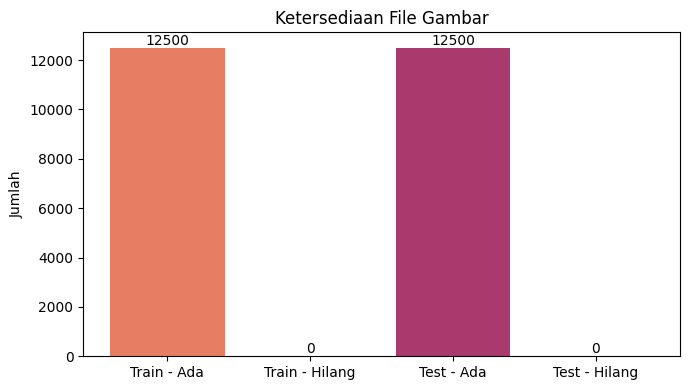

[OK] Semua file tersedia


In [7]:
def find_missing(df, images_dir):
    return [fid for fid in df['Image'] if not (images_dir / fid).exists()]

train_missing = find_missing(train_df, CFG.TRAIN_IMG_DIR)
test_missing  = find_missing(test_df,  CFG.TEST_IMG_DIR)

print(f'Train  total : {len(train_df)}')
print(f'Train  hilang: {len(train_missing)}')
print(f'Test   total : {len(test_df)}')
print(f'Test   hilang: {len(test_missing)}')

fig, ax = plt.subplots(figsize=(7, 4))
categories = ['Train - Ada', 'Train - Hilang', 'Test - Ada', 'Test - Hilang']
counts = [
    len(train_df) - len(train_missing), len(train_missing),
    len(test_df)  - len(test_missing),  len(test_missing),
]
colors = sns.color_palette(CFG.PALETTE, n_colors=4)
bars = ax.bar(categories, counts, color=colors)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom')
ax.set(title='Ketersediaan File Gambar', ylabel='Jumlah')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_01_file_hilang.png', dpi=150, bbox_inches='tight')
plt.show()

# Hapus baris yang file-nya tidak ada
if train_missing:
    train_df = train_df[~train_df['Image'].isin(train_missing)].reset_index(drop=True)
    print(f'[OK] {len(train_missing)} baris dihapus dari train_df')
if test_missing:
    test_df = test_df[~test_df['Image'].isin(test_missing)].reset_index(drop=True)
    print(f'[OK] {len(test_missing)} baris dihapus dari test_df')
if not train_missing and not test_missing:
    print('[OK] Semua file tersedia')

> **Insight:** ...

## Analisis 2: Pengecekan Duplikat

> Apakah terdapat gambar duplikat di dalam *training set* maupun antara *training set* dan *test set*?

Setiap gambar di-*hash* menggunakan SHA-256 untuk menghasilkan sidik jari unik berbasis konten. Dua gambar dengan nilai *hash* yang sama dipastikan identik secara piksel, terlepas dari nama file. Pemeriksaan dilakukan pada dua arah, yaitu duplikat di dalam *training set* (train-train) dan gambar yang muncul di *training set* sekaligus di *test set* (train-test).

In [8]:
def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()

print('Menghitung hash SHA-256 untuk seluruh gambar...')
train_df['sha256'] = [
    sha256_file(CFG.TRAIN_IMG_DIR / fid)
    for fid in tqdm(train_df['Image'], desc='Train')
]
test_df['sha256'] = [
    sha256_file(CFG.TEST_IMG_DIR / fid)
    for fid in tqdm(test_df['Image'], desc='Test')
]

# Train-train duplicates
train_hash_counts = train_df['sha256'].value_counts()
dup_hashes_tt     = train_hash_counts[train_hash_counts > 1]
dup_train         = train_df[train_df['sha256'].isin(dup_hashes_tt.index)]

# Train-test duplicates
test_hashes  = set(test_df['sha256'])
dup_train_test = train_df[train_df['sha256'].isin(test_hashes)]

print(f'Duplikat train-train : {len(dup_train)} gambar ({len(dup_hashes_tt)} hash unik)')
print(f'Duplikat train-test  : {len(dup_train_test)} gambar dari train muncul di test')

if not dup_train.empty:
    print('\nContoh duplikat train-train:')
    display(dup_train.sort_values('sha256').head(10))
if not dup_train_test.empty:
    print('\nContoh duplikat train-test:')
    display(dup_train_test.head(10))

Menghitung hash SHA-256 untuk seluruh gambar...


Test: 100%|██████████| 12500/12500 [00:30<00:00, 405.68it/s]

Duplikat train-train : 4 gambar (2 hash unik)
Duplikat train-test  : 4 gambar dari train muncul di test

Contoh duplikat train-train:


,Image,Species_Label,sha256
3693,868706bd-6777-462c-ac9f-242f8c129482.jpg,0,ab450d3e54342dfee7b694acd6322c9bc18ad56b8e670b...
11701,18502752-7b7f-4fc5-91a0-7b9f481bd31f.jpg,0,ab450d3e54342dfee7b694acd6322c9bc18ad56b8e670b...
1085,292663ac-40fe-4739-8b15-7d7ac03b744e.jpg,1,cd1a0a452fcd1b3f790838ee0dd17a3fecde50739c8d19...
10354,62dce045-51aa-464a-9816-0e8fad9fb73c.jpg,1,cd1a0a452fcd1b3f790838ee0dd17a3fecde50739c8d19...



Contoh duplikat train-test:


,Image,Species_Label,sha256
616,ab01d5ad-304f-4235-9026-60140ef8ee4f.jpg,0,9970ef96246b1575e1364184a941918c06a2964c9685d4...
1085,292663ac-40fe-4739-8b15-7d7ac03b744e.jpg,1,cd1a0a452fcd1b3f790838ee0dd17a3fecde50739c8d19...
5327,f4fe6dab-164c-492e-a085-771e26533c65.jpg,0,066041419e93d7df9693db1e41705add9f8a42e4c63a67...
10354,62dce045-51aa-464a-9816-0e8fad9fb73c.jpg,1,cd1a0a452fcd1b3f790838ee0dd17a3fecde50739c8d19...


> **Insight:** ...

## Analisis 3: Distribusi Kelas

> Apakah *dataset* seimbang antara kelas kucing dan anjing?

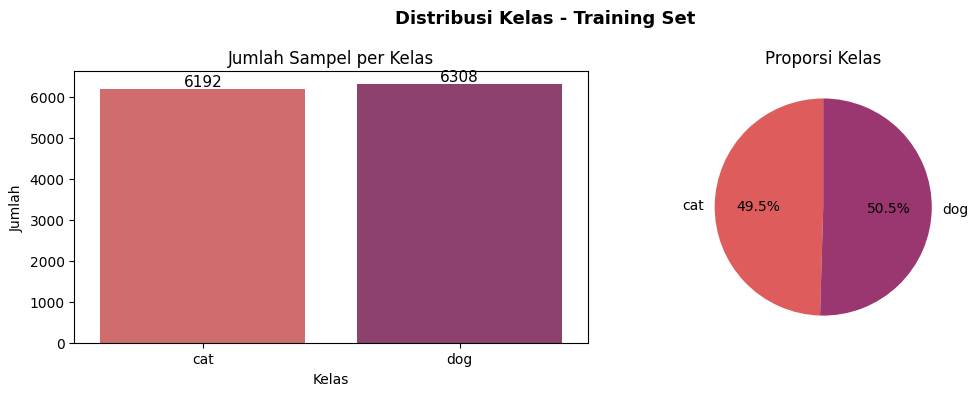

Species_Label
0    6192
1    6308
Rasio kelas : cat=6192 : dog=6308


In [9]:
label_counts = train_df[CFG.TARGET_COL].value_counts().sort_index()
class_labels = [CFG.CLASS_NAMES[i] for i in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
sns.barplot(x=class_labels, y=label_counts.values,
            palette=CFG.PALETTE, ax=axes[0])
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 str(val), ha='center', va='bottom', fontsize=11)
axes[0].set(title='Jumlah Sampel per Kelas', xlabel='Kelas', ylabel='Jumlah')

# Pie chart
axes[1].pie(label_counts.values, labels=class_labels, autopct='%1.1f%%',
            colors=sns.color_palette(CFG.PALETTE, n_colors=len(class_labels)),
            startangle=90)
axes[1].set_title('Proporsi Kelas')

plt.suptitle('Distribusi Kelas - Training Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_03_distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

print(label_counts.to_string())
ratio = ' : '.join(f'{CFG.CLASS_NAMES[i]}={label_counts.get(i, 0)}' for i in range(CFG.N_CLASSES))
print(f'Rasio kelas : {ratio}')

> **Insight:** ...

## Analisis 4: Distribusi Ukuran Gambar

> Apakah dimensi gambar konsisten di seluruh *dataset*?

Reading sizes: 100%|██████████| 12500/12500 [00:06<00:00, 1865.33it/s]


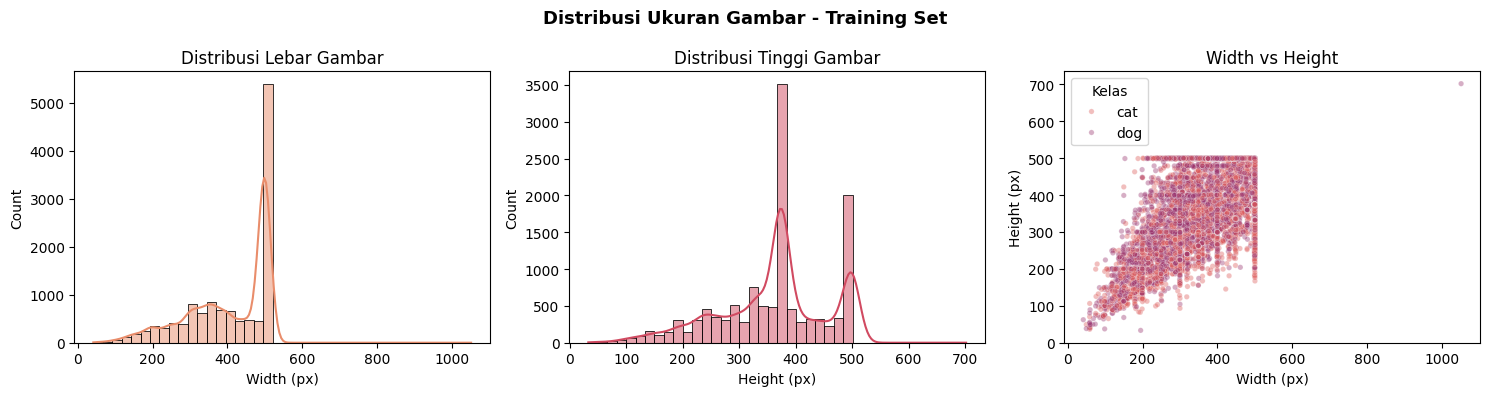

         width   height   aspect
count  12500.0  12500.0  12500.0
mean     404.2    361.2      1.2
std      109.2     96.6      0.3
min       42.0     33.0      0.3
25%      324.0    306.8      0.9
50%      447.0    374.0      1.3
75%      499.0    422.0      1.3
max     1050.0    702.0      5.9
Kombinasi ukuran unik: 5017


In [10]:
def collect_sizes(df, images_dir):
    widths, heights = [], []
    for fid in tqdm(df['Image'], desc='Reading sizes', leave=True):
        with Image.open(images_dir / fid) as img:
            w, h = img.size
        widths.append(w)
        heights.append(h)
    return widths, heights

train_w, train_h = collect_sizes(train_df, CFG.TRAIN_IMG_DIR)
train_df['width']  = train_w
train_df['height'] = train_h
train_df['aspect'] = train_df['width'] / train_df['height']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Width distribution
sns.histplot(train_df['width'], bins=40, kde=True,
             color=sns.color_palette(CFG.PALETTE)[0], ax=axes[0])
axes[0].set(title='Distribusi Lebar Gambar', xlabel='Width (px)', ylabel='Count')

# Height distribution
sns.histplot(train_df['height'], bins=40, kde=True,
             color=sns.color_palette(CFG.PALETTE)[2], ax=axes[1])
axes[1].set(title='Distribusi Tinggi Gambar', xlabel='Height (px)', ylabel='Count')

# Width vs Height scatter
sns.scatterplot(data=train_df, x='width', y='height',
                hue=CFG.TARGET_COL, palette=CFG.PALETTE,
                alpha=0.4, s=15, ax=axes[2])
axes[2].set(title='Width vs Height', xlabel='Width (px)', ylabel='Height (px)')
handles, _ = axes[2].get_legend_handles_labels()
axes[2].legend(handles, CFG.CLASS_NAMES, title='Kelas')

plt.suptitle('Distribusi Ukuran Gambar - Training Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_04_distribusi_ukuran.png', dpi=150, bbox_inches='tight')
plt.show()

print(train_df[['width', 'height', 'aspect']].describe().round(1))
n_unique = train_df.groupby(['width', 'height']).ngroups
print(f'Kombinasi ukuran unik: {n_unique}')

> **Insight:** ...

## Analisis 5: Pemeriksaan Mode Gambar

> Apakah semua gambar bertipe RGB, atau terdapat mode lain seperti grayscale atau RGBA?

Mode gambar menentukan jumlah channel yang diterima model. Gambar grayscale (`L`) hanya memiliki 1 channel, sementara `RGBA` memiliki 4 channel, keduanya tidak kompatibel dengan bobot pretrained yang mengharapkan 3 channel RGB. Hasil analisis ini menentukan apakah konversi `.convert('RGB')` wajib diterapkan di dalam `Dataset`.

Mode check: 100%|██████████| 12500/12500 [00:07<00:00, 1760.45it/s]


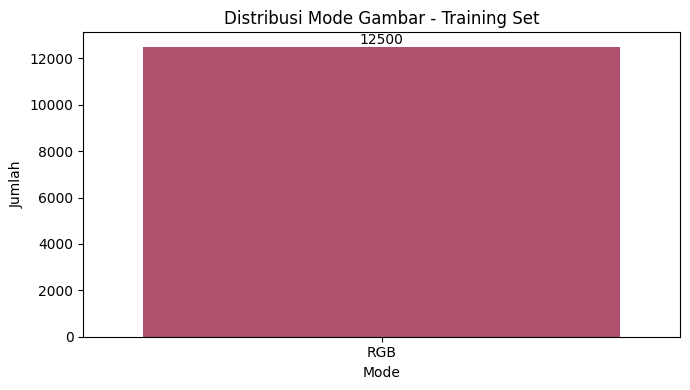

Mode counts : {'RGB': 12500}
Non-RGB     : tidak ada
.convert("RGB") : opsional (semua sudah RGB)


In [11]:
modes = []
for fid in tqdm(train_df['Image'], desc='Mode check', leave=True):
    with Image.open(CFG.TRAIN_IMG_DIR / fid) as img:
        modes.append(img.mode)
train_df['img_mode'] = modes
mode_counts = Counter(modes)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=list(mode_counts.keys()), y=list(mode_counts.values()),
            palette=CFG.PALETTE, ax=ax)
for bar, val in zip(ax.patches, mode_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom')
ax.set(title='Distribusi Mode Gambar - Training Set', xlabel='Mode', ylabel='Jumlah')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_05_mode_gambar.png', dpi=150, bbox_inches='tight')
plt.show()

non_rgb = {k: v for k, v in mode_counts.items() if k != 'RGB'}
print(f'Mode counts : {dict(mode_counts)}')
print(f'Non-RGB     : {non_rgb if non_rgb else "tidak ada"}')
print(f'.convert("RGB") : {"wajib" if non_rgb else "opsional (semua sudah RGB)"}')

> **Insight:** ...

## Analisis 6: Distribusi Rasio Aspek

> Seberapa beragam proporsi dimensi gambar, dan apakah banyak yang jauh dari persegi?

Rasio aspek (lebar/tinggi) menentukan seberapa banyak informasi yang hilang saat gambar diubah ukurannya menjadi persegi untuk input model. Gambar dengan rasio jauh dari 1.0 akan mengalami distorsi signifikan jika hanya di-*resize* tanpa *crop*, sehingga strategi `Resize` diikuti `CenterCrop` atau `RandomCrop` perlu dipertimbangkan.

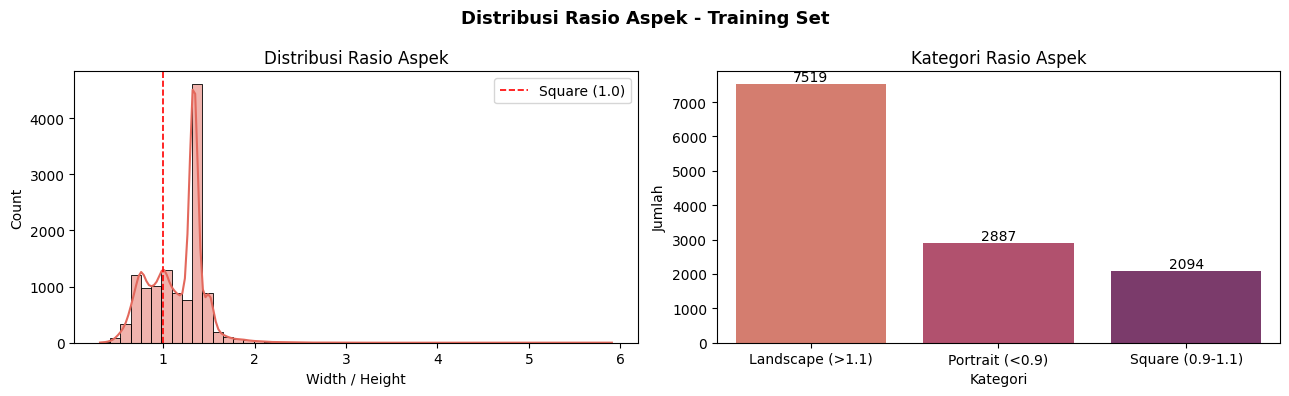

count    12500.000
mean         1.155
std          0.294
min          0.307
25%          0.926
50%          1.266
75%          1.337
max          5.909
Name: aspect, dtype: float64


In [12]:
# Kolom aspect sudah dihitung di Analisis 3
def aspect_cat(r):
    if r < 0.9:   return 'Portrait (<0.9)'
    elif r <= 1.1: return 'Square (0.9-1.1)'
    else:          return 'Landscape (>1.1)'

train_df['aspect_cat'] = train_df['aspect'].apply(aspect_cat)
cat_counts = train_df['aspect_cat'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(train_df['aspect'], bins=50, kde=True,
             color=sns.color_palette(CFG.PALETTE)[1], ax=axes[0])
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1.2, label='Square (1.0)')
axes[0].set(title='Distribusi Rasio Aspek', xlabel='Width / Height', ylabel='Count')
axes[0].legend()

sns.barplot(x=cat_counts.index, y=cat_counts.values,
            palette=CFG.PALETTE, ax=axes[1])
for bar, val in zip(axes[1].patches, cat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom')
axes[1].set(title='Kategori Rasio Aspek', xlabel='Kategori', ylabel='Jumlah')

plt.suptitle('Distribusi Rasio Aspek - Training Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_06_rasio_aspek.png', dpi=150, bbox_inches='tight')
plt.show()

print(train_df['aspect'].describe().round(3))

> **Insight:** ...

## Analisis 7: Distribusi Kecerahan dan Kontras

> Seberapa bervariasi tingkat kecerahan dan kontras gambar di dalam *training set*?

Kecerahan diukur sebagai rata-rata piksel ternormalisasi ([0, 1]) dan kontras sebagai standar deviasi piksel. Distribusi yang lebar pada salah satu dimensi menunjukkan bahwa augmentasi `ColorJitter(brightness=..., contrast=...)` akan membantu model belajar fitur yang lebih robust terhadap kondisi pencahayaan. Distribusi yang sempit sebaliknya mengindikasikan bahwa augmentasi tersebut kurang diperlukan dan berisiko menambah *noise*.

Brightness/Contrast: 100%|██████████| 12500/12500 [00:35<00:00, 351.71it/s]


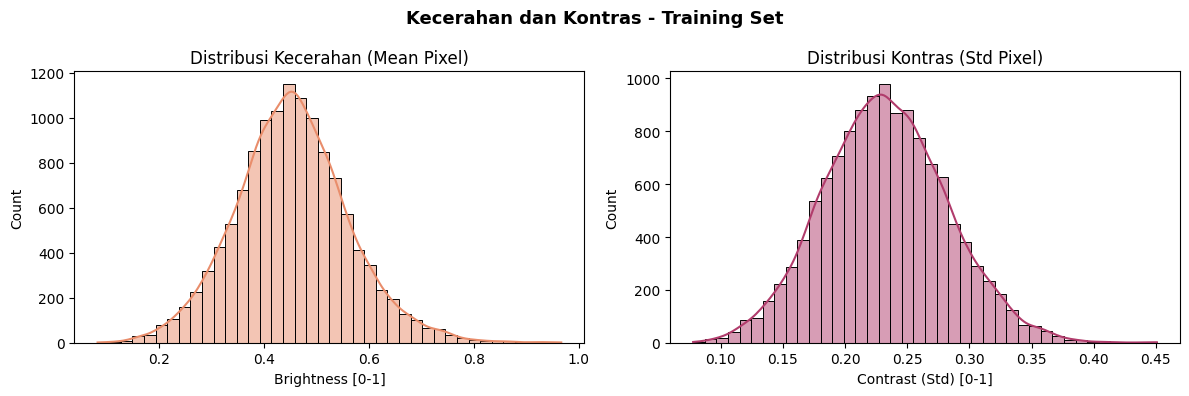

       brightness   contrast
count   12500.000  12500.000
mean        0.454      0.232
std         0.108      0.050
min         0.083      0.078
25%         0.384      0.198
50%         0.452      0.231
75%         0.520      0.265
max         0.967      0.451


In [13]:
brightnesses, contrasts = [], []
for fid in tqdm(train_df['Image'], desc='Brightness/Contrast', leave=True):
    with Image.open(CFG.TRAIN_IMG_DIR / fid) as img:
        arr = np.array(img.convert('RGB'), dtype=np.float32) / 255.0
    brightnesses.append(float(arr.mean()))
    contrasts.append(float(arr.std()))

train_df['brightness'] = brightnesses
train_df['contrast']   = contrasts

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_df['brightness'], bins=40, kde=True,
             color=sns.color_palette(CFG.PALETTE)[0], ax=axes[0])
axes[0].set(title='Distribusi Kecerahan (Mean Pixel)',
            xlabel='Brightness [0-1]', ylabel='Count')

sns.histplot(train_df['contrast'], bins=40, kde=True,
             color=sns.color_palette(CFG.PALETTE)[3], ax=axes[1])
axes[1].set(title='Distribusi Kontras (Std Pixel)',
            xlabel='Contrast (Std) [0-1]', ylabel='Count')

plt.suptitle('Kecerahan dan Kontras - Training Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_07_kecerahan_kontras.png', dpi=150, bbox_inches='tight')
plt.show()

print(train_df[['brightness', 'contrast']].describe().round(3))

> **Insight:** ...

## Analisis 8: Sampel Gambar per Kelas

> Seperti apa gambar aktual dalam *dataset* untuk setiap kelas?

Inspeksi visual mengungkap hal-hal yang tidak tertangkap oleh statistik: keberadaan *watermark*, border putih/hitam, gambar berkualitas rendah, sudut pengambilan tidak lazim, atau oklusi subjek. Temuan ini menentukan apakah augmentasi seperti `RandomRotation`, `RandomPerspective`, atau `GaussianBlur` relevan diterapkan.

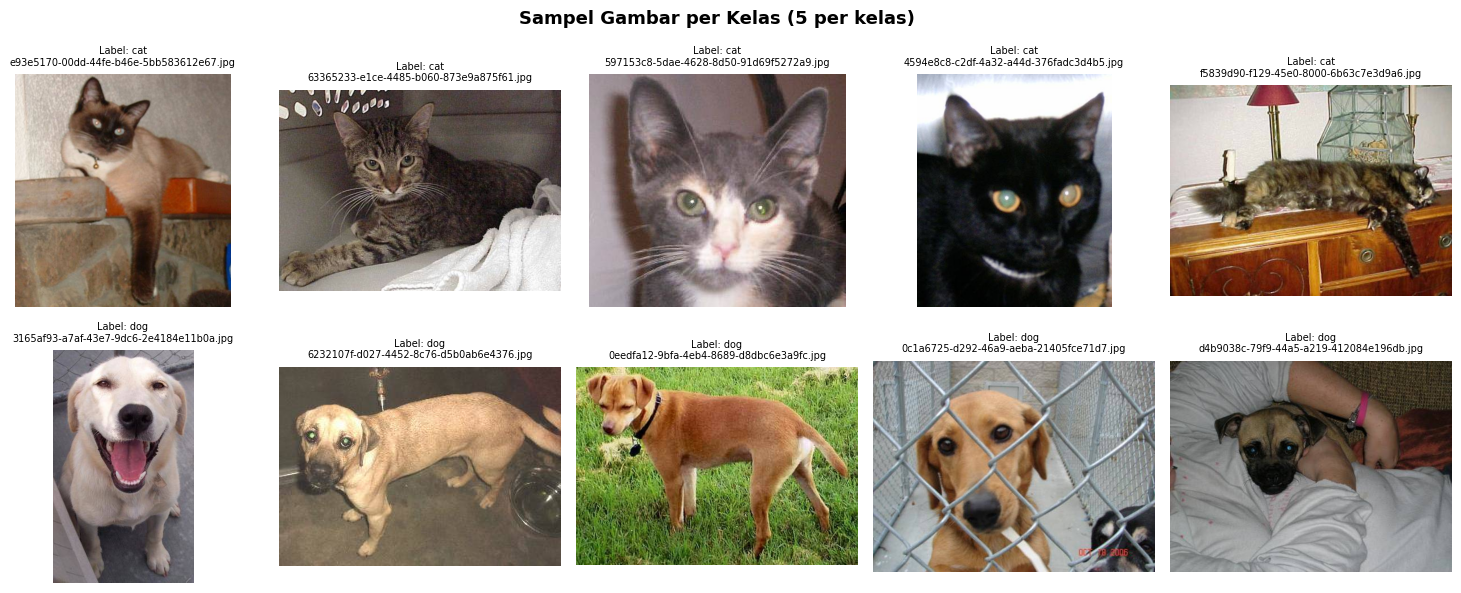

In [14]:
n_per_class = 5
fig, axes = plt.subplots(len(CFG.CLASS_NAMES), n_per_class,
                         figsize=(3 * n_per_class, 3 * len(CFG.CLASS_NAMES)))

for row, (cls_idx, cls_name) in enumerate(enumerate(CFG.CLASS_NAMES)):
    samples = (
        train_df[train_df[CFG.TARGET_COL] == cls_idx]
        .sample(n_per_class, random_state=CFG.SEED)
        .reset_index(drop=True)
    )
    for col in range(n_per_class):
        img = Image.open(CFG.TRAIN_IMG_DIR / samples.loc[col, 'Image'])
        axes[row, col].imshow(img)
        axes[row, col].set_title(
            f'Label: {cls_name}\n{samples.loc[col, "Image"]}',
            fontsize=7
        )
        axes[row, col].axis('off')

plt.suptitle('Sampel Gambar per Kelas (5 per kelas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_08_sampel_gambar.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insight:** ...

---

# Pembagian Data Latih dan Validasi <a name="2"></a>

---

Pembagian dilakukan **sebelum** prapemrosesan untuk mencegah kebocoran data (*data leakage*). Data latih asli sebelum pembagian disimpan karena akan digunakan kembali saat melatih model final untuk submisi Kaggle.

In [15]:
train_original = train_df.copy()  # simpan untuk pelatihan ulang saat submisi

train_set, val_set = train_test_split(
    train_df,
    test_size=CFG.VAL_SPLIT,
    random_state=CFG.SEED,
    stratify=train_df[CFG.TARGET_COL],
)
train_set = train_set.reset_index(drop=True)
val_set   = val_set.reset_index(drop=True)

print(f'Latih     : {len(train_set)} sampel')
print(f'Validasi  : {len(val_set)} sampel')
print(f'Distribusi kelas (latih):\n{train_set[CFG.TARGET_COL].value_counts()}')

Latih     : 10000 sampel
Validasi  : 2500 sampel
Distribusi kelas (latih):
Species_Label
1    5046
0    4954
Name: count, dtype: int64


---

# Pembersihan dan Prapemrosesan Data <a name="3"></a>

---

Data mentah jarang siap digunakan langsung untuk pelatihan. Setiap langkah prapemrosesan yang dilakukan disertai penjelasan alasan pemilihannya pada sel *markdown* di bawah kode. Untuk pemrosesan gambar, dapat digunakan OpenCV, PIL, *torchvision*, Keras, atau pustaka lain yang sesuai.

## Langkah Prapemrosesan 1

In [16]:
# Tulis kode di sini


**Alasan:** ...

## Langkah Prapemrosesan 2

In [17]:
# Tulis kode di sini


**Alasan:** ...

## Kompilasi Pipeline Prapemrosesan

Transformasi akhir didefinisikan untuk data latih dan validasi. Transformasi data latih menyertakan augmentasi untuk meningkatkan variasi, sedangkan transformasi validasi bersifat deterministik.

In [18]:
# RandomResizedCrop handles the wide aspect-ratio range (0.3-5.9) seen in EDA
# without squashing images the way a bare Resize(224,224) does.
# Val uses Resize(256)+CenterCrop(224): the standard ImageNet eval protocol
# that matches how ResNet-50 weights were originally validated.
# ColorJitter targets the brightness spread (min=0.08, std=0.11) from EDA.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(CFG.IMG_SIZE[0], scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=CFG.IMAGENET_MEAN, std=CFG.IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CFG.IMG_SIZE[0]),
    transforms.ToTensor(),
    transforms.Normalize(mean=CFG.IMAGENET_MEAN, std=CFG.IMAGENET_STD),
])

## Dataset dan DataLoader

In [19]:
class PetDataset(Dataset):
    def __init__(self, df, images_dir, transform=None, has_label=True):
        self.df          = df.reset_index(drop=True)
        self.images_dir  = Path(images_dir)
        self.transform   = transform
        self.has_label   = has_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.images_dir / row['Image']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        if self.has_label:
            return img, int(row[CFG.TARGET_COL])
        return img


train_ds = PetDataset(train_set, CFG.TRAIN_IMG_DIR, transform=train_transform)
val_ds   = PetDataset(val_set,   CFG.TRAIN_IMG_DIR, transform=val_transform)
test_ds  = PetDataset(test_df,   CFG.TEST_IMG_DIR,  transform=val_transform, has_label=False)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f'Batch latih    : {len(train_loader)}')
print(f'Batch validasi : {len(val_loader)}')

Batch latih    : 313
Batch validasi : 79


---

# Pemodelan dan Validasi <a name="4"></a>

---

Dua model dibangun dan dibandingkan, yaitu AlexNet yang diimplementasikan dari nol menggunakan PyTorch serta model *pretrained* berbasis CNN yang di-*fine-tune* pada *dataset* ini. Metrik validasi yang digunakan adalah **macro F1-score**.

## 4.1 Convolutional Neural Network

### Training Utilities

In [20]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for imgs, labels in tqdm(loader, leave=True):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.autocast(device_type='cuda', enabled=CFG.USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss  += loss.item() * len(labels)
        preds_all   += logits.argmax(1).cpu().tolist()
        labels_all  += labels.cpu().tolist()
    avg_loss = total_loss / len(loader.dataset)
    f1       = f1_score(labels_all, preds_all, average='macro')
    return avg_loss, f1


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss  += loss.item() * len(labels)
        preds_all   += logits.argmax(1).cpu().tolist()
        labels_all  += labels.cpu().tolist()
    avg_loss = total_loss / len(loader.dataset)
    f1       = f1_score(labels_all, preds_all, average='macro')
    return avg_loss, f1, preds_all, labels_all


def run_training(model, train_loader, val_loader, checkpoint_path,
                 epochs=CFG.EPOCHS, lr=CFG.LR_ALEX,
                 early_stop_patience=CFG.EARLY_STOP_PATIENCE):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=CFG.WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    scaler    = torch.cuda.amp.GradScaler(enabled=CFG.USE_AMP)
    best_f1   = 0.0
    no_improve = 0
    history   = []
    for epoch in range(1, epochs + 1):
        tr_loss, tr_f1 = train_one_epoch(model, train_loader, optimizer,
                                          criterion, scaler)
        vl_loss, vl_f1, _, _ = evaluate(model, val_loader, criterion)
        history.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_f1': tr_f1,
                         'vl_loss': vl_loss, 'vl_f1': vl_f1})
        print(f'Epoch {epoch:02d}/{epochs}  '
              f'train_loss={tr_loss:.4f}  train_f1={tr_f1:.4f}  '
              f'val_loss={vl_loss:.4f}  val_f1={vl_f1:.4f}')
        if vl_f1 > best_f1:
            best_f1   = vl_f1
            no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f'  [OK] Checkpoint disimpan (val_f1={best_f1:.4f})')
        else:
            no_improve += 1
            if no_improve >= early_stop_patience:
                print(f'  [Early Stop] Tidak ada perbaikan selama {early_stop_patience} epoch.')
                break
    print(f'Val macro F1 terbaik: {best_f1:.4f}')
    return history


def _split_params(model):
    """Pisahkan parameter kepala (head) dan backbone berdasarkan nama layer."""
    head, backbone = [], []
    for name, param in model.named_parameters():
        if 'classifier' in name or name.startswith('fc.'):
            head.append(param)
        else:
            backbone.append(param)
    return head, backbone


def _unfreeze_last_blocks(model, n=2):
    """Unfreeze n blok terakhir backbone.

    Untuk model dengan model.features (EfficientNet, ConvNeXt, MobileNet):
    unfreeze n child terakhir dari model.features.
    Untuk model tanpa model.features (ResNet, ResNeXt, ShuffleNet):
    unfreeze n named child terakhir selain 'fc' dan 'avgpool'.
    """
    if hasattr(model, 'features'):
        blocks = list(model.features.children())
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
    else:
        named = [(nm, m) for nm, m in model.named_children()
                 if nm not in ('fc', 'avgpool')]
        for _, module in named[-n:]:
            for p in module.parameters():
                p.requires_grad = True


def run_finetuning(model, train_loader, val_loader, checkpoint_path,
                   epochs=CFG.EPOCHS, lr_head=CFG.LR_HEAD,
                   lr_backbone=CFG.LR_BACKBONE,
                   warmup_patience=CFG.WARMUP_PATIENCE,
                   warmup_min_delta=CFG.WARMUP_MIN_DELTA,
                   unfreeze_blocks=CFG.UNFREEZE_BLOCKS,
                   early_stop_patience=CFG.EARLY_STOP_PATIENCE,
                   cosine_t_max=CFG.COSINE_T_MAX):
    """Dua-fase fine-tuning dengan auto-detect transisi fase dan early stopping.

    Fase 1 (warm-up): backbone dibekukan, hanya kepala yang dilatih.
    Transisi terjadi otomatis saat val_loss tidak membaik >= warmup_min_delta
    selama warmup_patience epoch berturut-turut.
    Fase 2 (fine-tune): n blok terakhir backbone di-unfreeze dengan lr_backbone;
    kepala tetap menggunakan lr_head. Early stopping diterapkan pada fase 2
    berdasarkan val macro F1 dengan toleransi early_stop_patience epoch.
    Checkpoint terbaik disimpan berdasarkan val macro F1 di kedua fase.
    """
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    scaler    = torch.cuda.amp.GradScaler(enabled=CFG.USE_AMP)
    best_f1   = 0.0
    history   = []

    # --- Fase 1: warm-up kepala ---
    for p in model.parameters():
        p.requires_grad = False
    head_params, _ = _split_params(model)
    for p in head_params:
        p.requires_grad = True

    optimizer     = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head, weight_decay=CFG.WEIGHT_DECAY
    )
    best_val_loss = float('inf')
    no_improve    = 0
    phase1_end    = epochs   # fallback: tetap di fase 1 jika tidak pernah stabil

    for epoch in range(1, epochs + 1):
        tr_loss, tr_f1 = train_one_epoch(model, train_loader, optimizer,
                                          criterion, scaler)
        vl_loss, vl_f1, _, _ = evaluate(model, val_loader, criterion)
        history.append({'epoch': epoch, 'phase': 1,
                         'tr_loss': tr_loss, 'tr_f1': tr_f1,
                         'vl_loss': vl_loss, 'vl_f1': vl_f1})
        print(f'[Fase 1] Ep {epoch:02d}/{epochs}  '
              f'train_loss={tr_loss:.4f}  train_f1={tr_f1:.4f}  '
              f'val_loss={vl_loss:.4f}  val_f1={vl_f1:.4f}')

        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), checkpoint_path)
            print(f'  [OK] Checkpoint disimpan (val_f1={best_f1:.4f})')

        if best_val_loss - vl_loss > warmup_min_delta:
            best_val_loss = vl_loss
            no_improve    = 0
        else:
            no_improve += 1

        if no_improve >= warmup_patience:
            phase1_end = epoch
            print(f'[Fase 1] Kepala stabil setelah {epoch} epoch. Beralih ke fine-tune.')
            break

    if phase1_end >= epochs:
        print(f'Val macro F1 terbaik: {best_f1:.4f}')
        return history

    # --- Fase 2: unfreeze blok terakhir backbone ---
    _unfreeze_last_blocks(model, n=unfreeze_blocks)
    head_p, backbone_p = _split_params(model)

    optimizer = torch.optim.Adam([
        {'params': [p for p in backbone_p if p.requires_grad], 'lr': lr_backbone},
        {'params': [p for p in head_p    if p.requires_grad], 'lr': lr_head},
    ], weight_decay=CFG.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cosine_t_max
    )
    no_improve = 0

    for epoch in range(phase1_end + 1, epochs + 1):
        tr_loss, tr_f1 = train_one_epoch(model, train_loader, optimizer,
                                          criterion, scaler)
        vl_loss, vl_f1, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        history.append({'epoch': epoch, 'phase': 2,
                         'tr_loss': tr_loss, 'tr_f1': tr_f1,
                         'vl_loss': vl_loss, 'vl_f1': vl_f1})
        print(f'[Fase 2] Ep {epoch:02d}/{epochs}  '
              f'train_loss={tr_loss:.4f}  train_f1={tr_f1:.4f}  '
              f'val_loss={vl_loss:.4f}  val_f1={vl_f1:.4f}')

        if vl_f1 > best_f1:
            best_f1    = vl_f1
            no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f'  [OK] Checkpoint disimpan (val_f1={best_f1:.4f})')
        else:
            no_improve += 1
            if no_improve >= early_stop_patience:
                print(f'  [Early Stop] Tidak ada perbaikan selama {early_stop_patience} epoch.')
                break

    print(f'Val macro F1 terbaik: {best_f1:.4f}')
    return history

### 4.1.1 Model AlexNet dari Nol

AlexNet terdiri dari 5 lapisan konvolusi (dengan ReLU dan *max-pooling*) diikuti 3 lapisan *fully connected*. Lapisan *dense* terakhir disesuaikan menghasilkan 2 logit untuk klasifikasi biner kucing/anjing.

In [21]:
class AlexNet(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            # Conv1
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv2
            nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv3
            nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            # Conv4
            nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            # Conv5
            nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096), nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


alexnet = AlexNet(num_classes=CFG.N_CLASSES)
n_params = sum(p.numel() for p in alexnet.parameters() if p.requires_grad)
print(f'Parameter AlexNet: {n_params:,}')

Parameter AlexNet: 58,289,538


#### AlexNet Training

In [22]:
seed_everything(CFG.SEED)
alexnet      = AlexNet(num_classes=CFG.N_CLASSES)
alex_history = run_training(alexnet, train_loader, val_loader,
                            CFG.CHECKPOINT_ALEX)

100%|██████████| 313/313 [00:58<00:00,  5.36it/s]


Epoch 01/30  train_loss=0.6834  train_f1=0.5567  val_loss=0.6727  val_f1=0.5160
  [OK] Checkpoint disimpan (val_f1=0.5160)


100%|██████████| 313/313 [00:58<00:00,  5.34it/s]


Epoch 02/30  train_loss=0.6349  train_f1=0.6439  val_loss=0.5985  val_f1=0.6891
  [OK] Checkpoint disimpan (val_f1=0.6891)


100%|██████████| 313/313 [00:59<00:00,  5.30it/s]


...

Epoch 14/30  train_loss=0.2663  train_f1=0.8889  val_loss=0.2803  val_f1=0.8822


100%|██████████| 313/313 [01:01<00:00,  5.13it/s]


Epoch 15/30  train_loss=0.2502  train_f1=0.8927  val_loss=0.2691  val_f1=0.8812


100%|██████████| 313/313 [01:00<00:00,  5.21it/s]


Epoch 16/30  train_loss=0.2326  train_f1=0.9034  val_loss=0.2801  val_f1=0.8746
  [Early Stop] Tidak ada perbaikan selama 5 epoch.
Val macro F1 terbaik: 0.8884


#### Learning Curve - AlexNet

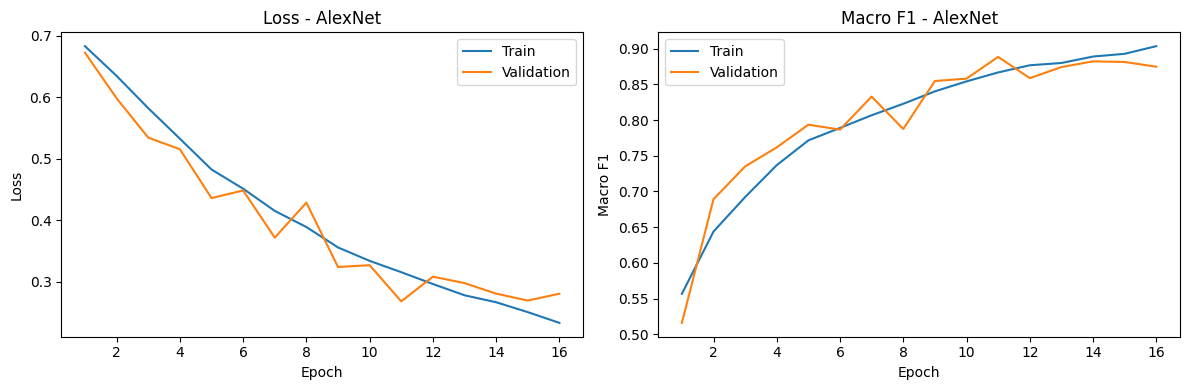

In [23]:
hist_df = pd.DataFrame(alex_history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['tr_loss'], label='Train')
axes[0].plot(hist_df['epoch'], hist_df['vl_loss'], label='Validation')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Loss - AlexNet')
axes[0].legend()
axes[1].plot(hist_df['epoch'], hist_df['tr_f1'], label='Train')
axes[1].plot(hist_df['epoch'], hist_df['vl_f1'], label='Validation')
axes[1].set(xlabel='Epoch', ylabel='Macro F1', title='Macro F1 - AlexNet')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_alexnet_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.1.2 Fine-tuning Model Pretrained

*Backbone* CNN *pretrained* pada ImageNet dimuat lalu lapisan keluarannya diganti dengan lapisan linear untuk klasifikasi biner. Seluruh pilihan *backbone* di bawah merupakan arsitektur CNN murni tanpa blok *attention* atau *transformer*. Ganti nilai `CFG.PRETRAINED_MODEL` di Settings untuk mencoba *backbone* yang berbeda.

In [24]:
def build_pretrained(name: str, num_classes: int = 2):
    """Muat backbone CNN (IMAGENET1K_V2) dan ganti kepala keluarannya.

    Semua backbone menggunakan IMAGENET1K_V2 weights.
    Nilai yang didukung untuk CFG.PRETRAINED_MODEL:
        'resnext101_32x8d'   ResNeXt-101-32x8d  82.8% top-1
        'wide_resnet101_2'   Wide-ResNet-101-2  82.5% top-1
        'resnet152'          ResNet-152         82.3% top-1
        'resnet101'          ResNet-101         81.9% top-1
        'wide_resnet50_2'    Wide-ResNet-50-2   81.6% top-1
        'resnext50_32x4d'    ResNeXt-50-32x4d   81.2% top-1
        'resnet50'           ResNet-50          80.9% top-1
        'mobilenet_v3_large' MobileNet-V3-L     75.3% top-1
    """
    # Semua ResNet-family: head = model.fc
    if name == 'resnet50':
        model = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    elif name == 'resnet101':
        model = tv_models.resnet101(weights=tv_models.ResNet101_Weights.IMAGENET1K_V2)
    elif name == 'resnet152':
        model = tv_models.resnet152(weights=tv_models.ResNet152_Weights.IMAGENET1K_V2)
    elif name == 'resnext50_32x4d':
        model = tv_models.resnext50_32x4d(weights=tv_models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)
    elif name == 'resnext101_32x8d':
        model = tv_models.resnext101_32x8d(weights=tv_models.ResNeXt101_32X8D_Weights.IMAGENET1K_V2)
    elif name == 'wide_resnet50_2':
        model = tv_models.wide_resnet50_2(weights=tv_models.Wide_ResNet50_2_Weights.IMAGENET1K_V2)
    elif name == 'wide_resnet101_2':
        model = tv_models.wide_resnet101_2(weights=tv_models.Wide_ResNet101_2_Weights.IMAGENET1K_V2)
    elif name == 'mobilenet_v3_large':
        model = tv_models.mobilenet_v3_large(weights=tv_models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        return model
    else:
        raise ValueError(f'Backbone tidak dikenal: {name!r}. Lihat opsi di CFG.PRETRAINED_MODEL.')

    # ResNet-family shared head replacement
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


pretrained_model = build_pretrained(CFG.PRETRAINED_MODEL, CFG.N_CLASSES)
n_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f'Backbone        : {CFG.PRETRAINED_MODEL}')
print(f'Parameter terlatih: {n_params:,}')

Downloading: "https://download.pytorch.org/models/resnext101_32x8d-110c445d.pth" to /root/.cache/torch/hub/checkpoints/resnext101_32x8d-110c445d.pth


100%|██████████| 340M/340M [00:08<00:00, 39.6MB/s]


Backbone        : resnext101_32x8d
Parameter terlatih: 86,746,434


#### Fine-tuning Training

In [25]:
seed_everything(CFG.SEED)
pretrained_model = build_pretrained(CFG.PRETRAINED_MODEL, CFG.N_CLASSES)
ft_history = run_finetuning(pretrained_model, train_loader, val_loader,
                            CFG.CHECKPOINT_FT)

100%|██████████| 313/313 [00:59<00:00,  5.28it/s]


[Fase 1] Ep 01/30  train_loss=0.1342  train_f1=0.9611  val_loss=0.0622  val_f1=0.9836
  [OK] Checkpoint disimpan (val_f1=0.9836)


100%|██████████| 313/313 [00:59<00:00,  5.24it/s]


[Fase 1] Ep 02/30  train_loss=0.0554  train_f1=0.9835  val_loss=0.0459  val_f1=0.9864
  [OK] Checkpoint disimpan (val_f1=0.9864)


100%|██████████| 313/313 [00:59<00:00,  5.24it/s]


...

[Fase 2] Ep 15/30  train_loss=0.0045  train_f1=0.9980  val_loss=0.0477  val_f1=0.9896


100%|██████████| 313/313 [01:55<00:00,  2.70it/s]


[Fase 2] Ep 16/30  train_loss=0.0067  train_f1=0.9985  val_loss=0.0185  val_f1=0.9932


100%|██████████| 313/313 [01:56<00:00,  2.70it/s]


[Fase 2] Ep 17/30  train_loss=0.0039  train_f1=0.9990  val_loss=0.0214  val_f1=0.9928
  [Early Stop] Tidak ada perbaikan selama 5 epoch.
Val macro F1 terbaik: 0.9952


#### Learning Curve - Fine-tuning

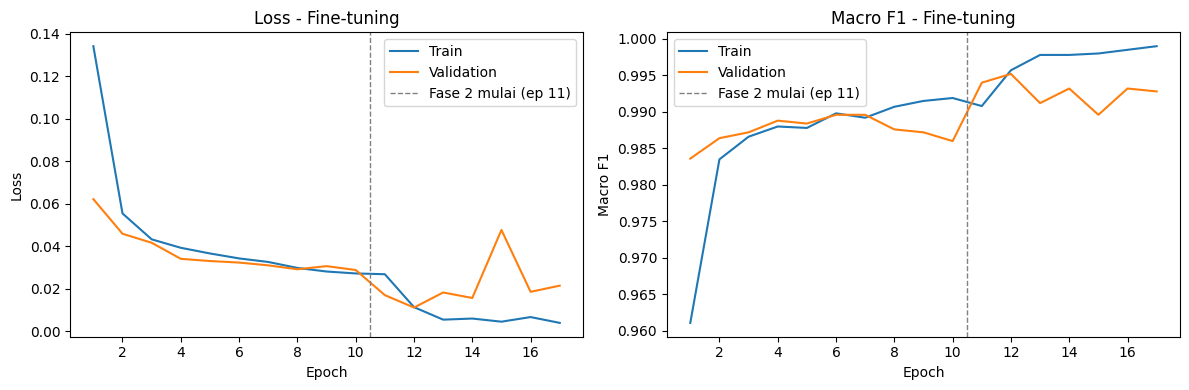

In [26]:
hist_df_ft   = pd.DataFrame(ft_history)
phase1_mask  = hist_df_ft['phase'] == 1
switch_epoch = int(hist_df_ft.loc[phase1_mask, 'epoch'].max()) if phase1_mask.any() else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_tr, y_vl, ylabel, title in [
    (axes[0], 'tr_loss', 'vl_loss', 'Loss',     'Loss - Fine-tuning'),
    (axes[1], 'tr_f1',  'vl_f1',  'Macro F1', 'Macro F1 - Fine-tuning'),
]:
    ax.plot(hist_df_ft['epoch'], hist_df_ft[y_tr], label='Train')
    ax.plot(hist_df_ft['epoch'], hist_df_ft[y_vl], label='Validation')
    if switch_epoch is not None and switch_epoch < hist_df_ft['epoch'].max():
        ax.axvline(switch_epoch + 0.5, color='gray', linestyle='--', linewidth=1,
                   label=f'Fase 2 mulai (ep {switch_epoch + 1})')
    ax.set(xlabel='Epoch', ylabel=ylabel, title=title)
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_finetune_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2 Validasi

Kedua model dievaluasi pada *validation set* menggunakan **macro F1-score**. Hasil yang harus tercantum di *notebook* mencakup hasil validasi kedua model wajib (AlexNet dan *pretrained*) serta hasil model submisi final di Kaggle.

In [27]:
criterion = nn.CrossEntropyLoss()

# Muat checkpoint terbaik masing-masing model
alexnet.load_state_dict(torch.load(CFG.CHECKPOINT_ALEX, map_location=DEVICE))
pretrained_model.load_state_dict(torch.load(CFG.CHECKPOINT_FT, map_location=DEVICE))

_, alex_f1, alex_preds, alex_labels = evaluate(alexnet, val_loader, criterion)
_, ft_f1,   ft_preds,   ft_labels   = evaluate(pretrained_model, val_loader, criterion)

print(f'AlexNet       val macro F1 : {alex_f1:.4f}')
print(f'Fine-tuned    val macro F1 : {ft_f1:.4f}')

print('\nClassification Report - AlexNet')
print(classification_report(alex_labels, alex_preds,
                            target_names=CFG.CLASS_NAMES))
print('\nClassification Report - Fine-tuned')
print(classification_report(ft_labels, ft_preds,
                            target_names=CFG.CLASS_NAMES))

AlexNet       val macro F1 : 0.8884
Fine-tuned    val macro F1 : 0.9952

Classification Report - AlexNet
              precision    recall  f1-score   support

         cat       0.88      0.90      0.89      1238
         dog       0.90      0.87      0.89      1262

    accuracy                           0.89      2500
   macro avg       0.89      0.89      0.89      2500
weighted avg       0.89      0.89      0.89      2500


Classification Report - Fine-tuned
              precision    recall  f1-score   support

         cat       0.99      1.00      1.00      1238
         dog       1.00      0.99      1.00      1262

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500



## Submisi

Kedua model diprediksi pada *test set* dan masing-masing disimpan ke file CSV terpisah. Upload file yang sesuai dengan model yang ingin disubmit ke Kaggle.

In [28]:
def predict_test(model, checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.to(DEVICE).eval()
    preds = []
    with torch.no_grad():
        for imgs in test_loader:
            imgs = imgs.to(DEVICE)
            preds.extend(model(imgs).argmax(1).cpu().tolist())
    return preds

# AlexNet submission
alex_test_preds = predict_test(alexnet, CFG.CHECKPOINT_ALEX)
sub_alex = pd.DataFrame({'Image': test_df['Image'], CFG.TARGET_COL: alex_test_preds})
sub_alex.to_csv(CFG.SUBMISSION_ALEX, index=False)
print(f'[OK] AlexNet  submisi disimpan di {CFG.SUBMISSION_ALEX}')

# Fine-tuned submission
ft_test_preds = predict_test(pretrained_model, CFG.CHECKPOINT_FT)
sub_ft = pd.DataFrame({'Image': test_df['Image'], CFG.TARGET_COL: ft_test_preds})
sub_ft.to_csv(CFG.SUBMISSION_FT, index=False)
print(f'[OK] Fine-tune submisi disimpan di {CFG.SUBMISSION_FT}')

print(f'\nAlexNet  val macro F1 : {alex_f1:.4f}')
print(f'Fine-tune val macro F1 : {ft_f1:.4f}')
sub_ft.head()

[OK] AlexNet  submisi disimpan di /kaggle/working/prak3/submission_alexnet.csv
[OK] Fine-tune submisi disimpan di /kaggle/working/prak3/submission_finetune.csv

AlexNet  val macro F1 : 0.8884
Fine-tune val macro F1 : 0.9952


,Image,Species_Label
0,865918b6-015d-4070-a18f-a6957154662b.jpg,0
1,c33dfd7c-2a0b-43bc-b184-ad5bc71589d1.jpg,1
2,28d53db6-4caf-4de9-9624-c61ecfa00c49.jpg,1
3,b46a6481-33a3-42e8-9bfd-9c507e3dce63.jpg,1
4,645d8cc3-9f63-4a5f-82a8-cc5654fca714.jpg,1


---

# Analisis Kesalahan <a name="5"></a>

---

Kesalahan prediksi model dianalisis untuk memahami penyebab utama ketidaktepatan klasifikasi. Beberapa pertanyaan panduan yang dapat digunakan:

1. Bagaimana distribusi kesalahan antarkelas? Apakah sebagian besar kesalahan berasal dari satu kelas?
2. Apakah *false positive* atau *false negative* yang lebih dominan?
3. Apakah oklusi atau sudut pengambilan gambar yang tidak biasa berkontribusi pada kesalahan?
4. Apakah pola tertentu terlihat pada sampel yang salah diklasifikasikan?

## Confusion Matrix

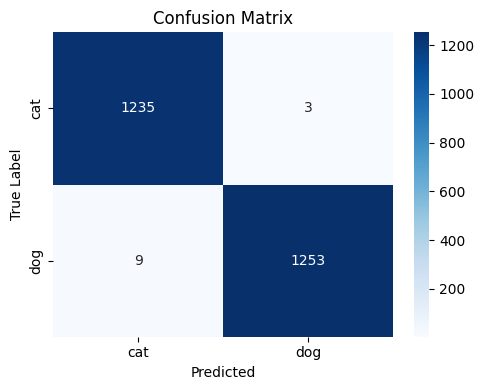

In [29]:
# Gunakan prediksi dari model terbaik pada validasi
best_preds  = ft_preds  if ft_f1 >= alex_f1 else alex_preds
best_labels = ft_labels if ft_f1 >= alex_f1 else alex_labels

cm = confusion_matrix(best_labels, best_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CFG.CLASS_NAMES, yticklabels=CFG.CLASS_NAMES, ax=ax)
ax.set(xlabel='Predicted', ylabel='True Label', title='Confusion Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'error_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Misclassified Samples

Salah diklasifikasikan: 12 / 2500


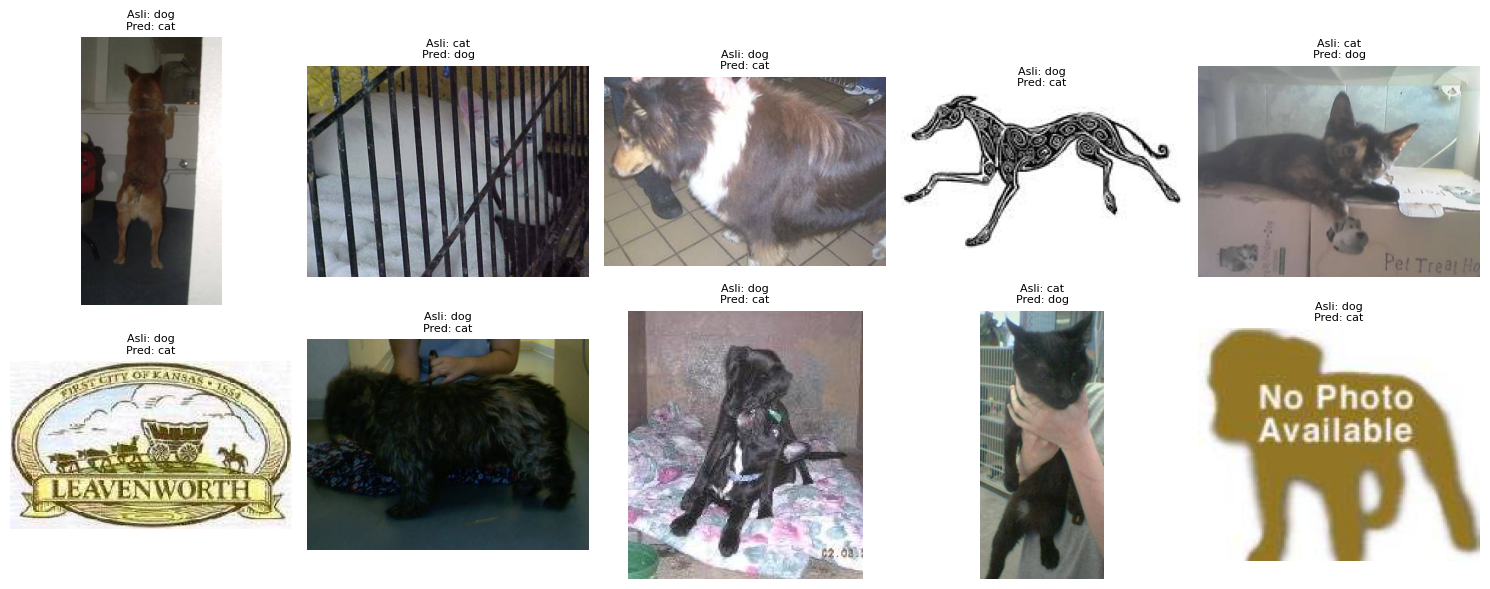

In [30]:
# Visualisasi gambar yang salah diklasifikasikan
wrong_idx = [i for i, (p, t) in enumerate(zip(best_preds, best_labels)) if p != t]
print(f'Salah diklasifikasikan: {len(wrong_idx)} / {len(best_labels)}')

n_show = min(10, len(wrong_idx))
n_cols = min(5, n_show)
n_rows = (n_show + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = np.array(axes).flatten()
for ax, idx in zip(axes[:n_show], wrong_idx[:n_show]):
    row = val_set.iloc[idx]
    img = Image.open(CFG.TRAIN_IMG_DIR / row['Image'])
    ax.imshow(img)
    ax.set_title(
        f'Asli: {CFG.CLASS_NAMES[best_labels[idx]]}\n'
        f'Pred: {CFG.CLASS_NAMES[best_preds[idx]]}',
        fontsize=8
    )
    ax.axis('off')
for ax in axes[n_show:]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'error_misclassified.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
print(f'Daftar sampel salah diklasifikasikan ({len(wrong_idx)} sampel)')
for rank, idx in enumerate(wrong_idx, 1):
    row = val_set.iloc[idx]
    true_label = CFG.CLASS_NAMES[best_labels[idx]]
    pred_label = CFG.CLASS_NAMES[best_preds[idx]]
    print(f'{rank:>3}. {row["Image"]}  true={true_label:<4}  pred={pred_label}')

Daftar sampel salah diklasifikasikan (12 sampel)
  1. 0cc601fc-d16f-4c72-91e4-9d417634c5f2.jpg  true=dog   pred=cat
  2. 57e89fd5-2e17-48d2-b401-e89bea109342.jpg  true=cat   pred=dog
  3. e85442bf-758c-4efa-b2ce-802d45010655.jpg  true=dog   pred=cat
  4. c95dcf93-d033-4bc4-aae4-8b9494c914e1.jpg  true=dog   pred=cat
  5. 4d27a322-60df-4f09-8fe3-fde5944f1cba.jpg  true=cat   pred=dog
  6. 06c65e33-a217-4788-b33a-83f8d85704c0.jpg  true=dog   pred=cat
  7. ad600e48-5178-4e60-a82e-1a881236e9b1.jpg  true=dog   pred=cat
  8. 03949897-3433-4cdc-930a-cdb7bba25a19.jpg  true=dog   pred=cat
  9. 39f69767-6726-4c91-ab4f-7a969802485c.jpg  true=cat   pred=dog
 10. d38b75b5-c3c3-45bd-9519-629f2a101cd2.jpg  true=dog   pred=cat
 11. 1e4127eb-420d-4db6-804f-0e60f2ac84e2.jpg  true=dog   pred=cat
 12. cc4f7bab-95de-4246-a31c-2dda2abaca20.jpg  true=dog   pred=cat


**Analisis:** ...

---

# Insights <a name="6"></a>

---

Setiap tahap pengerjaan disertai analisis dan argumen pendukung terhadap keputusan yang diambil.

## Insights EDA

> ...

## Insights Prapemrosesan

> ...

## Insights Pemodelan

> ...

## Insights Analisis Kesalahan

> ...

---

## Bundling Output

Seluruh gambar yang disimpan selama eksperimen dikemas ke dalam satu file zip untuk memudahkan pengumpulan dan dokumentasi. Checkpoint model tidak disertakan.

In [32]:
import zipfile as _zf

bundle_path = CFG.OUTPUT_DIR / 'figures_bundle.zip'
figures = sorted(FIG_DIR.glob('*.png'))

with _zf.ZipFile(bundle_path, 'w', _zf.ZIP_DEFLATED) as zf:
    for fig_path in figures:
        zf.write(fig_path, arcname=fig_path.name)

print(f'[OK] {len(figures)} gambar dikemas ke {bundle_path}')
for f in figures:
    print(f'  {f.name}')

[OK] 11 gambar dikemas ke /kaggle/working/prak3/figures_bundle.zip
  eda_01_file_hilang.png
  eda_03_distribusi_kelas.png
  eda_04_distribusi_ukuran.png
  eda_05_mode_gambar.png
  eda_06_rasio_aspek.png
  eda_07_kecerahan_kontras.png
  eda_08_sampel_gambar.png
  error_confusion_matrix.png
  error_misclassified.png
  model_alexnet_learning_curve.png
  model_finetune_learning_curve.png
